In [2]:
import pandas as pd, numpy as np

In [4]:
df = pd.read_csv('data/hitters.csv')

In [6]:
df.head()

,Unnamed: 0,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,#NAME?,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,#NAME?,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,#NAME?,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,#NAME?,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,#NAME?,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N


In [17]:
df.isnull().sum()

Unnamed: 0    0
AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary        0
NewLeague     0
dtype: int64

In [14]:
# Remove rows where Salary is NaN and update the dataframe
df = df.dropna(subset=['Salary'])

In [18]:
y = df['Salary']
X = df.drop(['Salary', 'League', 'Division', 'NewLeague','Unnamed: 0'], axis=1).astype('float64')

In [19]:
print(X.shape, y.shape)

(263, 16) (263,)


In [21]:
from sklearn.linear_model import RidgeCV
 
X_std = X/X.std()

rcv = RidgeCV(alphas=np.linspace(0.001,100,1000), cv=10)
rcv.fit(X_std,y)

print("Best Alpha:", rcv.alpha_)

Best Alpha: 100.0


In [23]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_std = X/X.std()

X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.3, random_state=42)

ridge = Ridge(alpha=rcv.alpha_)
ridge.fit(X_train, y_train)
mse = mean_squared_error(y_test, ridge.predict(X_test))
print(f"Test MSE: {mse:.2f}")

Test MSE: 163269.17


In [24]:
#PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
df = pd.read_csv('data/hitters.csv').dropna().drop('Unnamed: 0', axis=1)
y = df['Salary'].values
X = df.drop(['Salary', 'League', 'Division', 'NewLeague'], 
axis=1).astype('float64')


Cumulative variance explained:
  PC1: 45.3%
  PC2: 71.0%
  PC3: 81.8%
  PC4: 87.2%
  PC5: 91.6%
  PC6: 94.8%
  PC7: 96.4%
  PC8: 97.5%
  PC9: 98.4%
  PC10: 99.0%
  PC11: 99.3%
  PC12: 99.7%
  PC13: 99.9%
  PC14: 100.0%
  PC15: 100.0%
  PC16: 100.0%

Best number of PCs: 15, CV-MSE: 117757.78


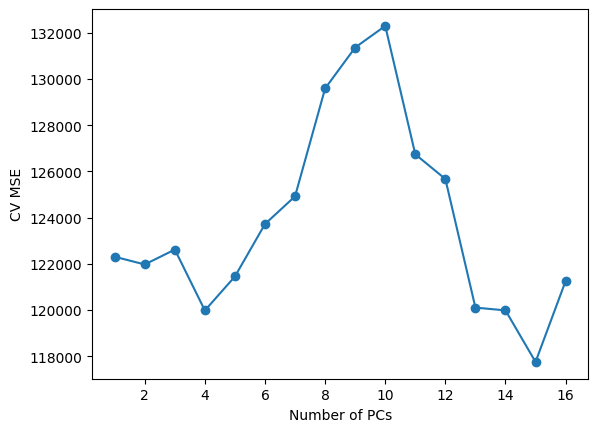

In [ ]:
pca = PCA()
X_reduced = pca.fit_transform(scale(X))
cum_var = np.cumsum(np.round(pca.explained_variance_ratio_, 4) * 100)

print("Cumulative variance explained:")
for i, v in enumerate(cum_var, 1):
    print(f"  PC{i}: {v:.1f}%")
# PCR via CV
kf = KFold(n_splits=10, shuffle=True, random_state=1)
lr = LinearRegression()
mse = []
for i in range(1, X_reduced.shape[1] + 1):
    scores = cross_val_score(lr, X_reduced[:, :i], y,
                scoring='neg_mean_squared_error', cv=kf)
    mse.append(-scores.mean())

best_m = np.argmin(mse) + 1
print(f"\nBest number of PCs: {best_m}, CV-MSE: {mse[best_m-1]:.2f}")
plt.plot(range(1, len(mse)+1), mse, '-o')
plt.xlabel('Number of PCs'); plt.ylabel('CV MSE'); plt.show()

In [ ]:
#PLOTTING

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is named 'default'
# ==========================================

# 1. SCATTER PLOT (Continuous vs. Continuous)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=default, x="balance", y="income", hue="default")
plt.title("Income vs Balance")
plt.xlabel("Credit Card Balance ($)")
plt.ylabel("Annual Income ($)")
plt.show()

# ==========================================

# 2. BOXPLOT (Categorical vs. Continuous Distribution)
plt.figure(figsize=(8, 5))
sns.boxplot(data=default, x="student", y="balance", palette="Set2")
plt.title("Balance Distribution by Student Status")
plt.xlabel("Is a Student?")
plt.ylabel("Credit Card Balance ($)")
plt.show()

# ==========================================

# 3. BARPLOT (Categorical vs. Numeric Mean/Aggregate)
plt.figure(figsize=(8, 5))
sns.barplot(data=default, x="student", y="income", palette="Pastel1")
plt.title("Average Income by Student Status")
plt.xlabel("Is a Student?")
plt.ylabel("Average Income ($)")
plt.show()